cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data
License(s): CC-BY-NC-SA-4.0
100% 48.6k/48.6k [00:00<00:00, 57.8MB/s]

Archive:  breast-cancer-wisconsin-data.zip
  inflating: data.csv                
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1      

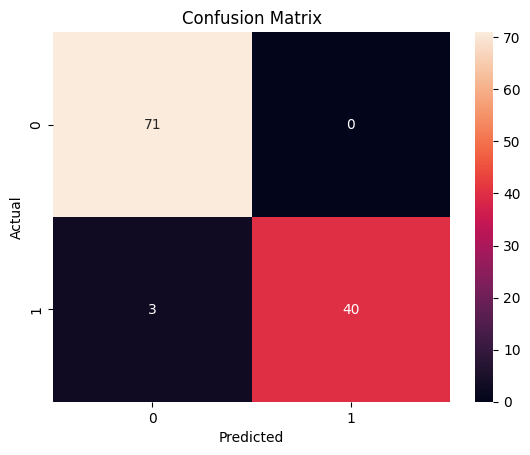

In [1]:
# ============================================
# STEP 1: Import Libraries
# ============================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt


# ============================================
# STEP 2: Setup Kaggle API
# ============================================

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


# ============================================
# STEP 3: Download Dataset from Kaggle
# ============================================

!kaggle datasets download -d uciml/breast-cancer-wisconsin-data


# ============================================
# STEP 4: Unzip Dataset
# ============================================

!unzip breast-cancer-wisconsin-data.zip


# ============================================
# STEP 5: Load Dataset
# ============================================

df = pd.read_csv("data.csv")

print(df.head())


# ============================================
# STEP 6: Dataset Info
# ============================================

print(df.info())


# ============================================
# STEP 7: Remove Unnecessary Columns
# ============================================

if 'Unnamed: 32' in df.columns:
    df.drop('Unnamed: 32', axis=1, inplace=True)

if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)

print(df.info())


# ============================================
# STEP 8: Convert Labels to Numbers
# ============================================

df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

print(df['diagnosis'].value_counts())


# ============================================
# STEP 9: Split Features and Labels
# ============================================

X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]


# ============================================
# STEP 10: Train-Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ============================================
# STEP 11: Train Gaussian Naive Bayes
# ============================================

model = GaussianNB()

model.fit(X_train, y_train)


# ============================================
# STEP 12: Predictions
# ============================================

y_pred = model.predict(X_test)


# ============================================
# STEP 13: Accuracy
# ============================================

acc = accuracy_score(y_test, y_pred)

print("Gaussian Naive Bayes Accuracy:", acc)


# ============================================
# STEP 14: Classification Report
# ============================================

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))


# ============================================
# STEP 15: Confusion Matrix
# ============================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n")

print(cm)


# ============================================
# STEP 16: Heatmap Visualization
# ============================================

sns.heatmap(cm, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()